In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('ipl_balls.csv')

print(f"Original dataset shape: {df.shape}")
df.head(3)

Original dataset shape: (294757, 24)


,match_id,date,team1,team2,batting_team,bowling_team,inning,over,ball_in_over,batter,...,is_wicket,total_runs_so_far,wickets_so_far,legal_balls_bowled,target,runs_required,balls_remaining,current_run_rate,required_run_rate,match_winner
0,1082591,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,1,DA Warner,...,0,0,0,1,NaN,NaN,NaN,NaN,NaN,Sunrisers Hyderabad
1,1082591,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,2,DA Warner,...,0,0,0,2,NaN,NaN,NaN,NaN,NaN,Sunrisers Hyderabad
2,1082591,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,3,DA Warner,...,0,4,0,3,NaN,NaN,NaN,NaN,NaN,Sunrisers Hyderabad


In [20]:
# Keep only 2nd innings 
chase_df = df[df['inning'] == 2].copy()

chase_df = chase_df.dropna(subset=['match_winner'])

chase_df = chase_df[
    (chase_df['match_winner'] == chase_df['team1']) | 
    (chase_df['match_winner'] == chase_df['team2'])
]

print(f"Dataset shape after filtering for clean chases: {chase_df.shape}")

Dataset shape after filtering for clean chases: (139802, 24)


In [21]:
chase_df['batting_team_won'] = (chase_df['batting_team'] == chase_df['match_winner']).astype(int)

chase_df['run_rate_diff'] = chase_df['current_run_rate'] - chase_df['required_run_rate']

features_to_keep = [
    'match_id', 
    'total_runs_so_far',
    'wickets_so_far',
    'balls_remaining',
    'runs_required',
    'current_run_rate',
    'required_run_rate',
    'run_rate_diff',
    'batting_team_won' 
]

ml_df = chase_df[features_to_keep].copy()

ml_df = ml_df.dropna()

ml_df.head()

,match_id,total_runs_so_far,wickets_so_far,balls_remaining,runs_required,current_run_rate,required_run_rate,run_rate_diff,batting_team_won
125,1082591,1,0,119.0,207.0,6.0,10.44,-4.44,0
126,1082591,1,0,118.0,207.0,3.0,10.53,-7.53,0
127,1082591,1,0,117.0,207.0,2.0,10.62,-8.62,0
128,1082591,3,0,116.0,205.0,4.5,10.60,-6.10,0
129,1082591,7,0,115.0,201.0,8.4,10.49,-2.09,0


In [22]:
unique_matches = ml_df['match_id'].unique()

train_match_ids, test_match_ids = train_test_split(unique_matches, test_size=0.2, random_state=42)

# Filter the rows based on the split match IDs
train_df = ml_df[ml_df['match_id'].isin(train_match_ids)]
test_df = ml_df[ml_df['match_id'].isin(test_match_ids)]

X_train = train_df.drop(columns=['match_id', 'batting_team_won'])
y_train = train_df['batting_team_won']

X_test = test_df.drop(columns=['match_id', 'batting_team_won'])
y_test = test_df['batting_team_won']

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (112141, 7)
Testing data shape: (27661, 7)


In [ ]:
# Initialize a simple Logistic Regression model
baseline_model = LogisticRegression()

# Fit the model on the training data
baseline_model.fit(X_train, y_train)

# Prediction of model on the unseen testing data
predictions = baseline_model.predict(X_test)

# Evaluate the accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Baseline Logistic Regression Accuracy: {accuracy * 100:.2f}%\n")

# Classification report
print("Detailed Performance Report:")
print(classification_report(y_test, predictions))

Baseline Logistic Regression Accuracy: 76.70%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75     13584
           1       0.75      0.81      0.78     14077

    accuracy                           0.77     27661
   macro avg       0.77      0.77      0.77     27661
weighted avg       0.77      0.77      0.77     27661



In [24]:
# Call predict_proba on the first 5 samples
probabilities = baseline_model.predict_proba(X_test[:5])

print("Probability output for the first 5 test samples (Class 0, Class 1):")
print(probabilities)
print("\nColumn 0 is the probability of losing, and Column 1 is the win probability between 0 and 1.")

Probability output for the first 5 test samples (Class 0, Class 1):
[[0.51187491 0.48812509]
 [0.44372228 0.55627772]
 [0.2843981  0.7156019 ]
 [0.35970513 0.64029487]
 [0.40821577 0.59178423]]

Column 0 is the probability of losing, and Column 1 is the win probability between 0 and 1.


In [25]:
from sklearn.metrics import log_loss

# Get probabilities for the entire test set
baseline_probs = baseline_model.predict_proba(X_test)

# Calculate and print log loss
baseline_log_loss = log_loss(y_test, baseline_probs)
print(f"Baseline Logistic Regression Log Loss: {baseline_log_loss:.4f}")

Baseline Logistic Regression Log Loss: 0.4786


In [26]:
from xgboost import XGBClassifier

# Initialize and train XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_log_loss = log_loss(y_test, xgb_probs)

print("--- Model Comparison ---")
print(f"Logistic Regression - Accuracy: {accuracy * 100:.2f}%, Log Loss: {baseline_log_loss:.4f}")
print(f"XGBoost             - Accuracy: {xgb_accuracy * 100:.2f}%, Log Loss: {xgb_log_loss:.4f}")

# Select the best model based on log loss
best_model = xgb_model if xgb_log_loss < baseline_log_loss else baseline_model
print(f"\nBest model selected for deployment: {type(best_model).__name__}")

--- Model Comparison ---
Logistic Regression - Accuracy: 76.70%, Log Loss: 0.4786
XGBoost             - Accuracy: 75.06%, Log Loss: 0.4971

Best model selected for deployment: LogisticRegression


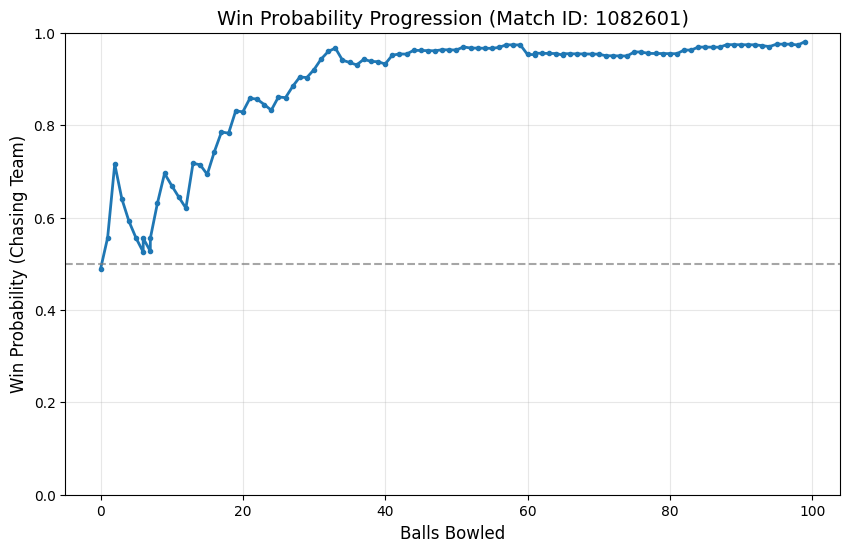

In [ ]:
# Pick the first unique match from the test set
sample_match_id = test_df['match_id'].iloc[0]
match_data = test_df[test_df['match_id'] == sample_match_id].copy()

# Sort by balls remaining (descending) to ensure chronological order of the innings
match_data = match_data.sort_values(by='balls_remaining', ascending=False)

# Extract the features for the model
X_match = match_data.drop(columns=['match_id', 'batting_team_won'])

# Get the win probability (Class 1) for each ball
match_probs = best_model.predict_proba(X_match)[:, 1]

# Calculate balls bowled for the x-axis
balls_bowled = 120 - match_data['balls_remaining']

# Plot the probability worm
plt.figure(figsize=(10, 6))
plt.plot(balls_bowled, match_probs, marker='.', linestyle='-', color='#1f77b4', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
plt.title(f'Win Probability Progression (Match ID: {sample_match_id})', fontsize=14)
plt.xlabel('Balls Bowled', fontsize=12)
plt.ylabel('Win Probability (Chasing Team)', fontsize=12)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
import joblib
joblib.dump(best_model, 'ipl_win_model.pkl')
print("Model saved successfully as ipl_win_model.pkl")

Model saved successfully as ipl_win_model.pkl
